# timeseries data

In [1]:
import torch

In [2]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'mps'

In [ ]:
# import requests
import tarfile
import urllib.request
from pathlib import Path

url = "https://github.com/ageron/data/raw/main/ridership.tgz"
download_dir = Path(r"/Users/mammadlisahriyar/Desktop/casual/ds_course/downloads")
download_dir.mkdir(parents=True, exist_ok=True)
download_path = download_dir / "ridership.tgz"

urllib.request.urlretrieve(url, download_path)

with tarfile.open(download_path) as f:
    f.extractall(path=download_dir, filter='data')

In [ ]:
csv_path = next(download_dir.glob(pattern="**/*.csv"))
csv_path

PosixPath('/Users/mammadlisahriyar/Desktop/casual/ds_course/downloads/ridership/CTA_-_Ridership_-_Daily_Boarding_Totals.csv')

In [17]:
import pandas as pd
import numpy as np

In [68]:
df = pd.read_csv(
    csv_path,
    parse_dates=['service_date']
    )
df.drop('total_rides', axis=1, inplace=True)
df.rename(columns={
    'service_date' : 'date',
    'rail_boardings' : 'rail'
}, inplace=True)
df.drop_duplicates(inplace=True)
df.set_index('date', inplace=True)
df.sort_index(inplace=True)
df.head(15)

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917
2001-01-06,A,577401,255356
2001-01-07,U,375831,169825
2001-01-08,W,985221,590706
2001-01-09,W,978377,599905


In [82]:
df['2019-03':'2019-05']

,day_type,bus,rail
date,,,
2019-03-01,W,812238,682969
2019-03-02,A,454119,349392
2019-03-03,U,313539,252150
2019-03-04,W,699086,635353
2019-03-05,W,761781,692945
...,...,...,...
2019-05-27,U,298987,256757
2019-05-28,W,769069,694292
2019-05-29,W,791059,717681


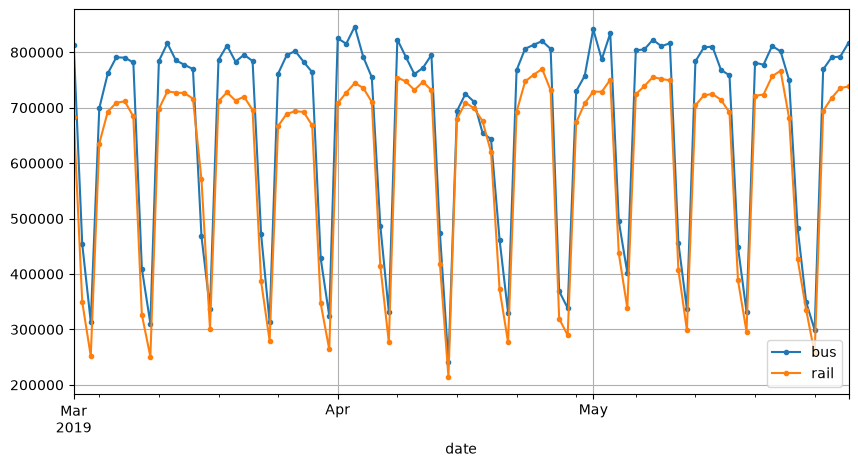

In [81]:
import matplotlib.pyplot as plt

df['2019-03':'2019-05'].plot(grid=True, figsize=(10,5), marker='.')
plt.show()

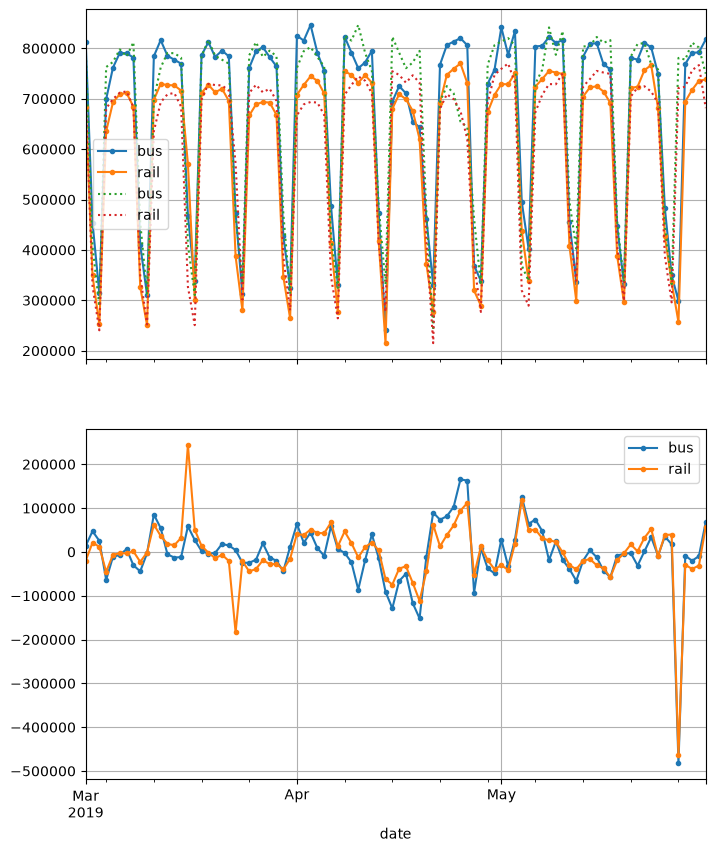

In [131]:
fig, axs = plt.subplots(2,1, figsize=(8,10), sharex=True)

df['2019-03':'2019-05'].plot(ax=axs[0], grid=True, marker='.')
df.shift(periods=7)['2019-03':'2019-05'].plot(ax=axs[0], grid=True, linestyle=':')

diff_7 = df.loc[:, ['bus','rail']].diff(7)['2019-03':'2019-05']
diff_7.plot(ax=axs[1],grid=True, marker='.')
plt.show()

In [136]:
diff_7.abs().mean()

bus     43915.608696
rail    42143.271739
dtype: float64

In [148]:
diff_7 = df.loc[:, ['bus','rail']].diff(7)['2019-03':'2019-05']
diff_7.abs()

,bus,rail
date,,
2019-03-01,13927.0,20019.0
2019-03-02,47280.0,21213.0
2019-03-03,25171.0,11672.0
2019-03-04,63771.0,45491.0
2019-03-05,11268.0,6517.0
...,...,...
2019-05-27,482074.0,464640.0
2019-05-28,8578.0,29490.0
2019-05-29,20317.0,38958.0


In [147]:
target = df.loc['2019-03':'2019-05', ['bus', 'rail']]
target

,bus,rail
date,,
2019-03-01,812238,682969
2019-03-02,454119,349392
2019-03-03,313539,252150
2019-03-04,699086,635353
2019-03-05,761781,692945
...,...,...
2019-05-27,298987,256757
2019-05-28,769069,694292
2019-05-29,791059,717681


In [151]:
mae = (diff_7.abs() / target).mean()
mae

bus     0.082938
rail    0.089948
dtype: float64

In [159]:
df['2001':'2019']

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917
...,...,...,...
2019-12-27,W,552198,445835
2019-12-28,A,394869,298646
2019-12-29,U,315428,251105


<Axes: xlabel='date'>

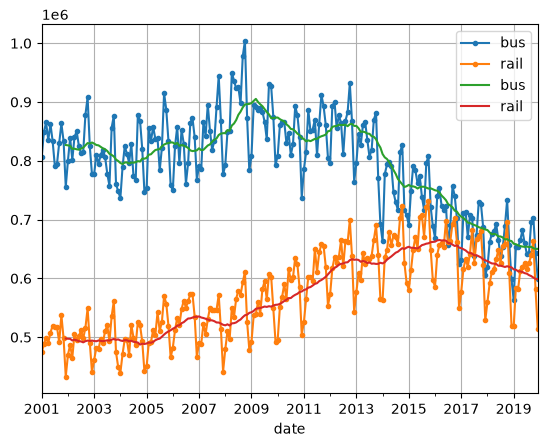

In [179]:
df_monthly = df.loc['2001':'2019', ['bus', 'rail']].resample('ME').mean()

fig, axs = plt.subplots()

df_monthly.plot(ax=axs, marker='.')

df_monthly.rolling(12).mean().plot(ax=axs, grid=True)

In [ ]:
torch.utils.data.Dataset()
torch.util

,bus,rail
date,,
2001-01-31,807190.580645,474591.419355
2001-02-28,848889.000000,488188.178571
2001-03-31,865392.419355,498825.096774
2001-04-30,835126.366667,490444.533333
2001-05-31,862701.419355,507862.258065
...,...,...
2019-08-31,643248.645161,626095.419355
2019-09-30,695255.966667,639273.933333
2019-10-31,703238.709677,663959.548387


,bus,rail
date,,
2001-01-31,NaN,NaN
2001-02-28,NaN,NaN
2001-03-31,NaN,NaN
2001-04-30,NaN,NaN
2001-05-31,NaN,NaN
...,...,...
2019-08-31,653301.645533,605589.250966
2019-09-30,653812.309421,603990.406522
2019-10-31,651295.035228,601386.350070


In [180]:
df

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917
...,...,...,...
2021-11-26,W,257700,189694
2021-11-27,A,237839,187065
2021-11-28,U,184817,147830


In [ ]:
297192, 780827